#### Heart Disease Prediction using Machine Learning:

Project Overview:

Early detection of heart disease is critical in reducing mortality rates.
This project builds and evaluates machine learning models to predict the presence of heart disease using patient clinical data.

Key focus areas:

Data cleaning and EDA

Feature engineering

Model building and optimization

Threshold tuning for medical risk reduction

Model interpretability and decision-making

Dataset Description :

Rows: 271

Target Variable: Heart Disease (0 = No, 1 = Yes)

Feature Summary

| Feature                 | Type      | Description             |
| ----------------------- | --------- | ----------------------- |
| Age                     | Numerical | Age of patient          |
| Sex                     | Binary    | 0 = Female, 1 = Male    |
| Chest pain Type         | Ordinal   | Type of chest pain      |
| BP                      | Numerical | Resting blood pressure  |
| Cholesterol             | Numerical | Serum cholesterol       |
| FBS Over 120            | Binary    | Blood sugar >120        |
| EKG Results             | Nominal   | ECG results             |
| Max HR                  | Numerical | Max heart rate          |
| Exercise Angina         | Binary    | Exercise-induced angina |
| ST Depression           | Numerical | ST depression           |
| Slope of ST             | Ordinal   | ST slope                |
| Number of Vessels Fluro | Ordinal   | Vessels via fluoroscopy |
| Thallium                | Nominal   | Thallium stress test    |
| Heart Disease           | Binary    | **Target**              |


#### Data Load & Cleaning :

In [33]:
import pandas as pd
import numpy as np

df = pd.read_csv("Heart_Disease_Prediction.csv")

df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0


In [34]:
# Basic Structure Check

df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    int64  
dtypes: float64(1), int64(13)
m

Summary statistics:

In [35]:
df.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296,0.444444
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659,0.497827
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000,0.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000,1.000000


Check missing values:

In [36]:
df.isnull().sum()

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

Heart Disease distribution:

In [37]:
df['Heart Disease'].value_counts() 

0    150
1    120
Name: Heart Disease, dtype: int64

    Observation : The target variable is reasonably balanced, so accuracy can be used as an evaluation metric.

#### Exploratory Data Analysis - EDA:

In [38]:
pd.crosstab(df['Sex'], df['Heart Disease'])
pd.crosstab(df['Chest pain type'], df['Heart Disease'])
pd.crosstab(df['Exercise angina'], df['Heart Disease'])
pd.crosstab(df['FBS over 120'], df['Heart Disease'])
pd.crosstab(df['EKG results'], df['Heart Disease'])

Heart Disease,0,1
EKG results,,
0,85,46
1,1,1
2,64,73


Numerical Feature Analysis:

In [39]:
df.groupby('Heart Disease')['Age'].mean()
df.groupby('Heart Disease')['Cholesterol'].mean()
df.groupby('Heart Disease')['Max HR'].mean()
df.groupby('Heart Disease')['ST depression'].mean()

Heart Disease
0    0.622667
1    1.584167
Name: ST depression, dtype: float64

EDA Visualization:

In [40]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: C:\Users\kalpa\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [41]:
!pip install seaborn


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: C:\Users\kalpa\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

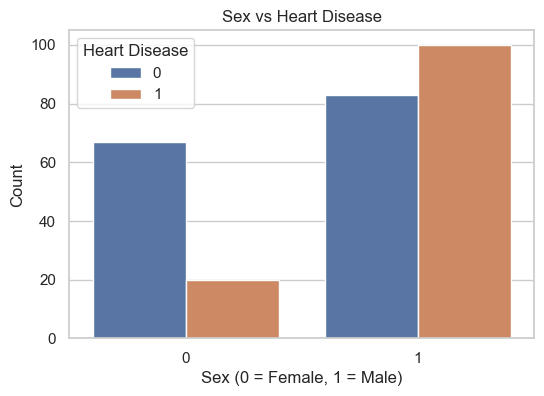

In [43]:
# Sex Vs Heart Disease

plt.figure(figsize=(6,4))
sns.countplot(x='Sex', hue='Heart Disease', data=df)
plt.title('Sex vs Heart Disease')
plt.xlabel('Sex (0 = Female, 1 = Male)')
plt.ylabel('Count')
plt.show()

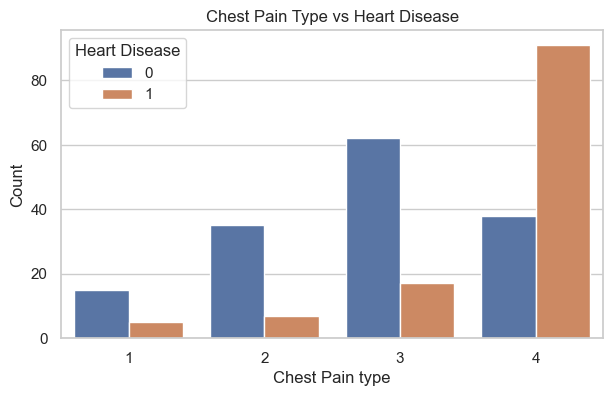

In [44]:
# Chest Pain Type vs Heart Disease

plt.figure(figsize=(7,4))
sns.countplot(x='Chest pain type', hue='Heart Disease', data=df)
plt.title('Chest Pain Type vs Heart Disease')
plt.xlabel('Chest Pain type')
plt.ylabel('Count')
plt.show()


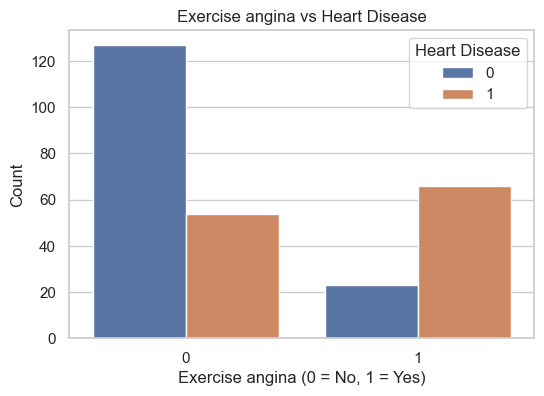

In [45]:
# Exercise Angina vs Heart Disease

plt.figure(figsize=(6,4))
sns.countplot(x='Exercise angina', hue='Heart Disease', data=df)
plt.title('Exercise angina vs Heart Disease')
plt.xlabel('Exercise angina (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

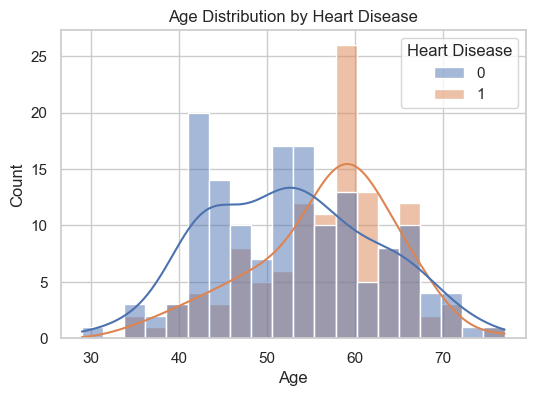

In [46]:
# Age distribution by Heart Disease

plt.figure(figsize=(6,4))
sns.histplot(data=df, x='Age', hue='Heart Disease', bins=20, kde=True)
plt.title('Age Distribution by Heart Disease')
plt.show()

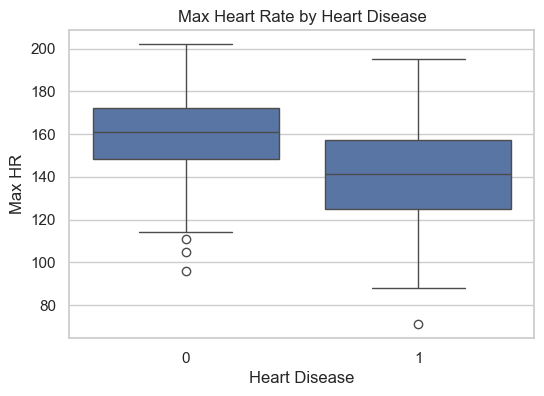

In [47]:
# Max Heart Rate vs Heart Disease

plt.figure(figsize=(6,4))
sns.boxplot(x='Heart Disease', y='Max HR', data=df)
plt.title('Max Heart Rate by Heart Disease')
plt.show()

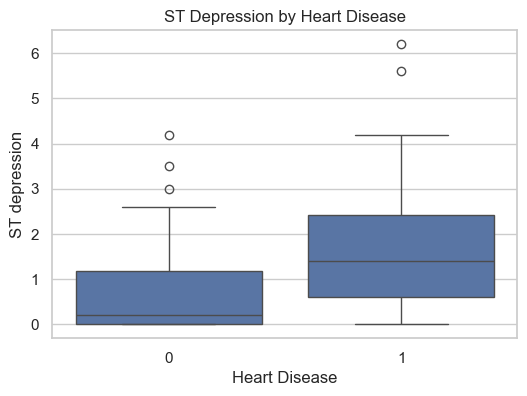

In [48]:
# ST Depression vs Heart Disease

plt.figure(figsize=(6,4))
sns.boxplot(x='Heart Disease', y='ST depression', data=df)
plt.title('ST Depression by Heart Disease')
plt.show()

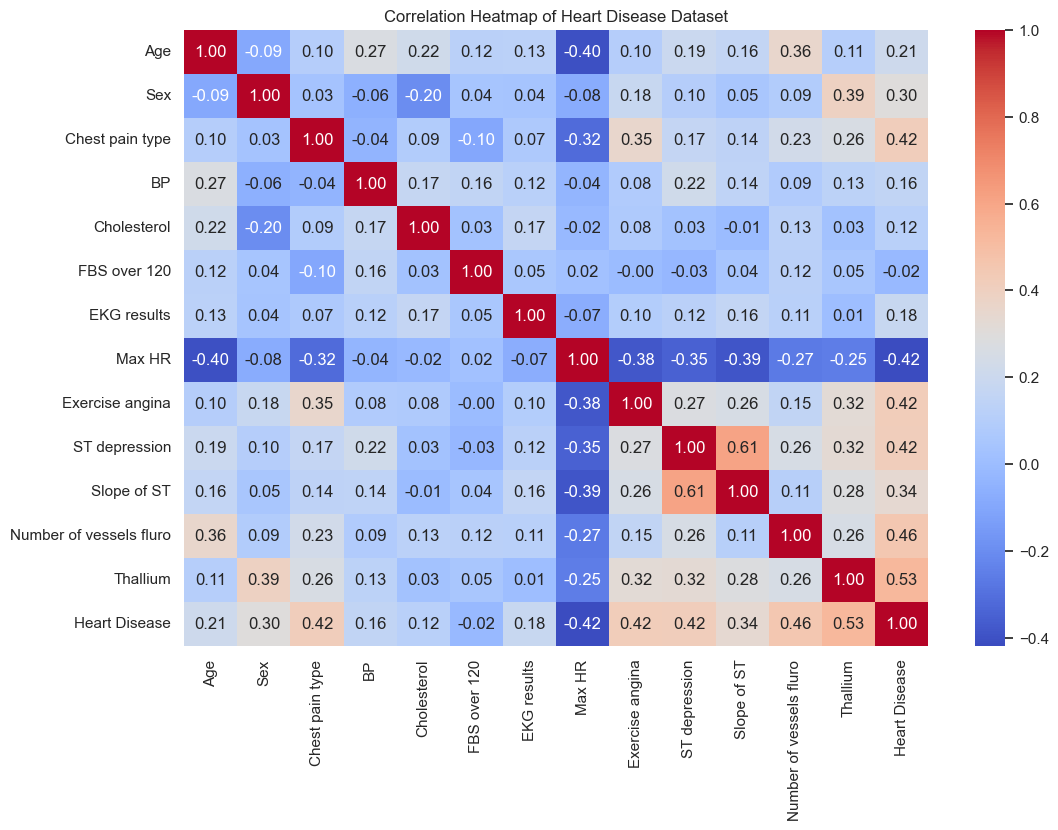

In [49]:
# Correlation between features

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Heart Disease Dataset")
plt.show()


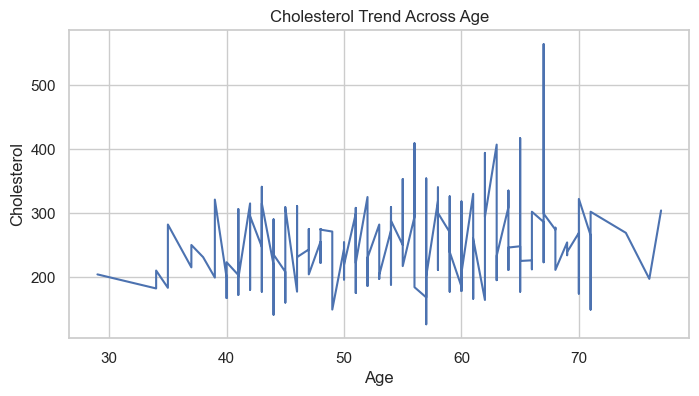

In [50]:
# Cholesterol Trend Across Age

df_sorted = df.sort_values('Age')

plt.figure(figsize=(8,4))
plt.plot(df_sorted['Age'], df_sorted['Cholesterol'])
plt.title('Cholesterol Trend Across Age')
plt.xlabel('Age')
plt.ylabel('Cholesterol')
plt.show()

#### ML Modeling:

##### Logistic Regression

Train–Test Split:

In [51]:
!pip install scikit-learn


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: C:\Users\kalpa\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [52]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Heart Disease'])
y = df['Heart Disease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [54]:
# import Model and Metrics

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [55]:
# Train the LG model

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


 Model Prediction and Evaluation:

In [56]:
y_pred = log_model.predict(X_test_scaled) # Predictions

# Evaluate the Model 

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Accuracy: 0.8518518518518519

Confusion Matrix:
[[24  6]
 [ 2 22]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.80      0.86        30
           1       0.79      0.92      0.85        24

    accuracy                           0.85        54
   macro avg       0.85      0.86      0.85        54
weighted avg       0.86      0.85      0.85        54



       Observation: The Logistic Regression model achieved 85% accuracy with a recall of 92% for heart disease cases, indicating strong capability in identifying patients at risk while maintaining low false-negative rates.

AUC - ROC Curve:

In [57]:
y_prob_lr = log_model.predict_proba(X_test_scaled)[:, 1]

from sklearn.metrics import roc_auc_score

auc_lr = roc_auc_score(y_test, y_prob_lr)
print("Logistic Regression AUC:", auc_lr)

Logistic Regression AUC: 0.898611111111111


##### Model Comparison with Random Forest:

In [58]:
from sklearn.ensemble import RandomForestClassifier

# Train the Model 

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [59]:
# Predict 

rf_pred = rf_model.predict(X_test)

In [60]:
# Evaluate 

print("Accuracy:", accuracy_score(y_test, rf_pred))
print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Accuracy: 0.8148148148148148
[[24  6]
 [ 4 20]]
              precision    recall  f1-score   support

           0       0.86      0.80      0.83        30
           1       0.77      0.83      0.80        24

    accuracy                           0.81        54
   macro avg       0.81      0.82      0.81        54
weighted avg       0.82      0.81      0.82        54



AUC-ROC Curve

In [61]:
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]


auc_rf = roc_auc_score(y_test, y_prob_rf)
print("Random Forest AUC:", auc_rf)

Random Forest AUC: 0.8673611111111111


    Observation: Built a Random Forest classification model achieving 81% accuracy with balanced precision and recall. model demonstrated strong performance in identifying critical class outcomes (Recall = 83%), supported by confusion matrix and F1-score evaluation

Side By Side Comparison of Models

In [62]:
import pandas as pd

model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [0.8519, 0.8148]
})

model_comparison


,Model,Accuracy
0,Logistic Regression,0.8519
1,Random Forest,0.8148


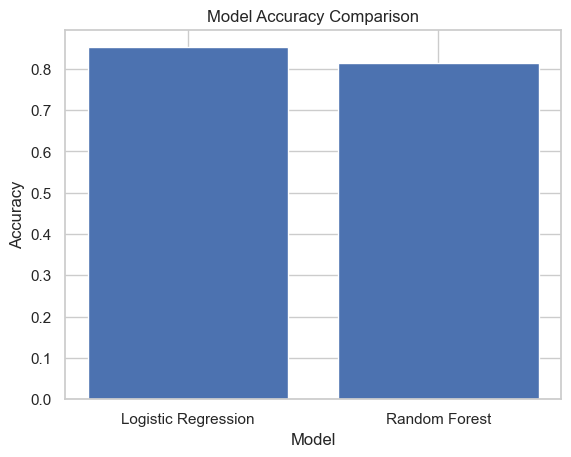

In [63]:
# Accuracy comparison

import matplotlib.pyplot as plt

plt.bar(model_comparison["Model"], model_comparison["Accuracy"])
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()


    observation: Logistic Regression slightly outperformed Random Forest with an accuracy of 85.19% compared to 81.48%. This suggests that the relationship between clinical features and heart disease is largely linear and interpretable, making Logistic Regression a suitable baseline model for medical prediction tasks.

In [64]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

In [65]:
# AUC - ROC curve Comparison

y_prob_lr = log_model.predict_proba(X_test_scaled)[:, 1]

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_rf = roc_auc_score(y_test, y_prob_rf)


print("Logistic Regression AUC:", auc_lr)
print("Random Forest AUC:", auc_rf)



Logistic Regression AUC: 0.898611111111111
Random Forest AUC: 0.8673611111111111


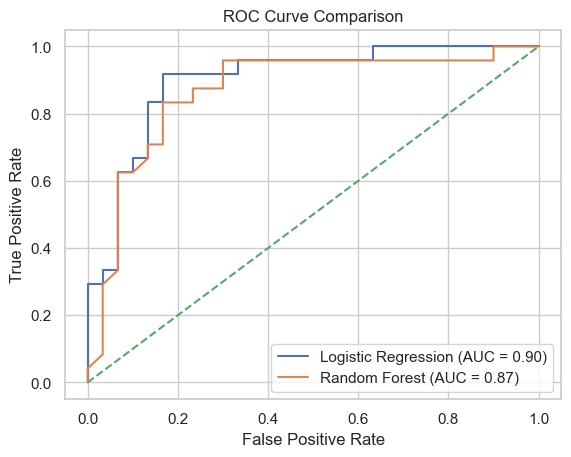

In [66]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure()
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

    Observation: Logistic Regression achieved the highest ROC–AUC score of 0.90, outperforming Random Forest (AUC = 0.87). This indicates strong discriminative capability while maintaining model interpretability, making Logistic Regression the preferred model for heart disease prediction.

##### Feature imporatnce for logistic regression:

In [67]:
# Get feature names
feature_names = X.columns  # make sure X is your original feature DataFrame

# Get coefficients from the trained Logistic Regression
coefficients = log_model.coef_[0]

# Create a DataFrame for viewing
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Sort by absolute impact
feature_importance['Abs_Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values(by='Abs_Coefficient', ascending=False)

feature_importance

,Feature,Coefficient,Abs_Coefficient
11,Number of vessels fluro,1.185769,1.185769
1,Sex,0.892690,0.892690
2,Chest pain type,0.716115,0.716115
12,Thallium,0.584150,0.584150
8,Exercise angina,0.481365,0.481365
10,Slope of ST,0.413009,0.413009
3,BP,0.408808,0.408808
7,Max HR,-0.399470,0.399470
5,FBS over 120,-0.347914,0.347914
4,Cholesterol,0.341274,0.341274


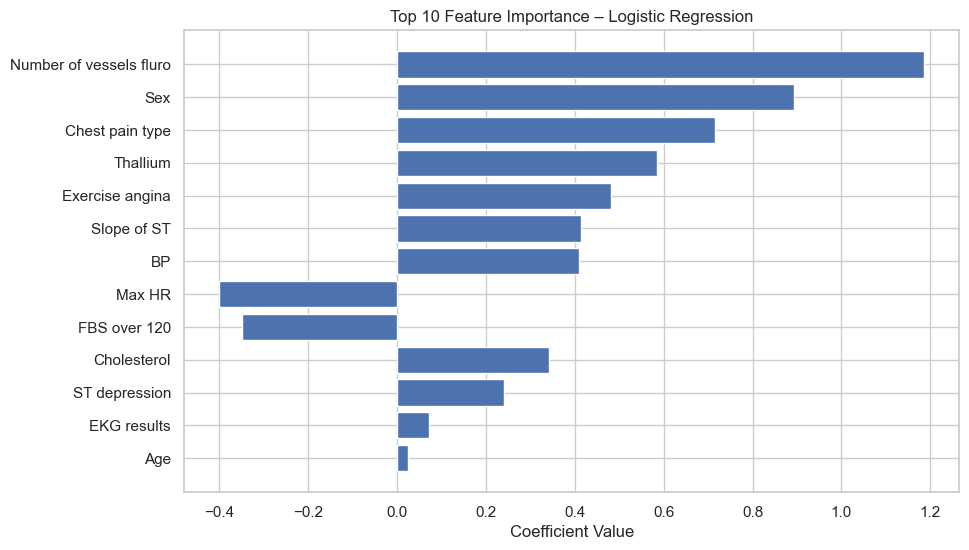

In [68]:
# Take top 15 features
top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))
plt.barh(top_features['Feature'], top_features['Coefficient'])
plt.xlabel("Coefficient Value")
plt.title("Top 10 Feature Importance – Logistic Regression")
plt.gca().invert_yaxis()  # largest on top
plt.show()

    Observation: The model identified Number of Vessels Fluro, Sex, Chest Pain Type, and Thallium scan results as the top predictors of heart disease. This aligns with medical knowledge: males with abnormal thallium results and more blocked vessels are at higher risk. Other features, such as Age, ST Depression, and Max Heart Rate, also influenced predictions, providing a comprehensive risk profile.

In [69]:
feature_imp =  pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(15)

print(feature_imp)

Chest pain type            0.129436
Max HR                     0.118366
ST depression              0.109802
Number of vessels fluro    0.108405
Thallium                   0.100866
Cholesterol                0.094452
Age                        0.083341
BP                         0.071727
Slope of ST                0.062165
Exercise angina            0.050438
Sex                        0.045102
EKG results                0.016691
FBS over 120               0.009210
dtype: float64


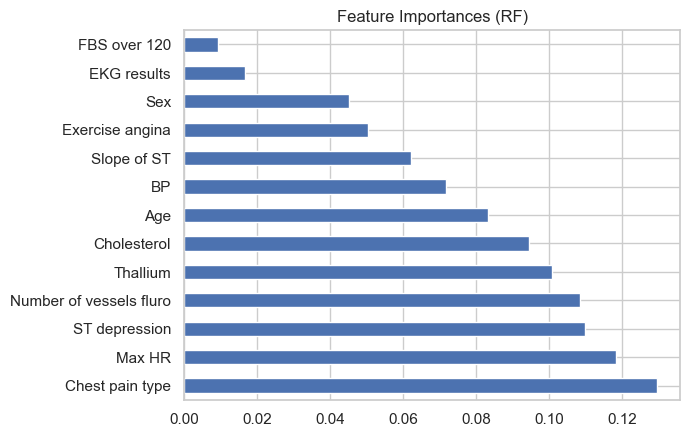

In [70]:
top_features_rf = feature_imp.head(15)
top_features_rf.plot.barh()
plt.title("Feature Importances (RF)")
plt.show()

Threshold Tuning for Logistic Regression:

In [71]:

from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# Define thresholds to test
thresholds = np.arange(0.1, 0.9, 0.1)

# Loop through thresholds
print("Threshold | Precision | Recall | F1-score | Confusion Matrix")
for t in thresholds:
    y_pred_thresh = (y_prob_lr >= t).astype(int)
    precision = precision_score(y_test, y_pred_thresh)
    recall = recall_score(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh)
    cm = confusion_matrix(y_test, y_pred_thresh)
    print(f"{t:.1f}      | {precision:.2f}      | {recall:.2f}   | {f1:.2f}    |    {cm}   ")

Threshold | Precision | Recall | F1-score | Confusion Matrix
0.1      | 0.59      | 0.96   | 0.73    |    [[14 16]
 [ 1 23]]   
0.2      | 0.70      | 0.96   | 0.81    |    [[20 10]
 [ 1 23]]   
0.3      | 0.73      | 0.92   | 0.81    |    [[22  8]
 [ 2 22]]   
0.4      | 0.76      | 0.92   | 0.83    |    [[23  7]
 [ 2 22]]   
0.5      | 0.79      | 0.92   | 0.85    |    [[24  6]
 [ 2 22]]   
0.6      | 0.81      | 0.88   | 0.84    |    [[25  5]
 [ 3 21]]   
0.7      | 0.80      | 0.67   | 0.73    |    [[26  4]
 [ 8 16]]   
0.8      | 0.84      | 0.67   | 0.74    |    [[27  3]
 [ 8 16]]   


    Observation: Threshold tuning was performed to balance precision and recall. A threshold of 0.5 was selected, achieving a recall of 92% while improving precision to 79%, minimizing missed heart disease cases while controlling false positives.

Hyperparameter Tuning for Random Forest:

In [72]:
# Hyperparameter tuning - Define Parameter Grid, and Grid search CV

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 5, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,300


    Train Random Forest with Best Parameters:

In [73]:
best_rf = grid.best_estimator_

rf_pred_best = best_rf.predict(X_test)
rf_prob_best = best_rf.predict_proba(X_test)[:, 1]

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

print("Accuracy:", accuracy_score(y_test, rf_pred_best))
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_pred_best))
print("Classification Report:\n", classification_report(y_test, rf_pred_best))

auc_rf_best = roc_auc_score(y_test, rf_prob_best)
print("Tuned RF ROC-AUC:", auc_rf_best)

print("Best RF Parameters:", grid.best_params_)

Accuracy: 0.8333333333333334
Confusion Matrix:
 [[25  5]
 [ 4 20]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.83      0.85        30
           1       0.80      0.83      0.82        24

    accuracy                           0.83        54
   macro avg       0.83      0.83      0.83        54
weighted avg       0.83      0.83      0.83        54

Tuned RF ROC-AUC: 0.8902777777777778
Best RF Parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 300}


#### Final Model (Tuned) Comparison:

| Metric           | Logistic Regression (Tuned) | Random Forest (Tuned) |
| ---------------- | --------------------------- | --------------------- |
| Accuracy         | **0.85**                    | 0.83                  |
| ROC-AUC          | **0.899**                   | 0.890                 |
| Recall (Disease) | **0.92**                    | 0.83                  |
| False Negatives  | **2**                       | 4                     |
| Interpretability | High                        | Medium                |


#### Final Model Selection:

Selected Model: Logistic Regression (Threshold Tuned - 0.5)

Reasons:

Highest recall

Lowest false negatives

Comparable ROC-AUC

In medical applications, minimizing missed diagnoses is more critical than marginal gains in precision.

#### Final Model Pipeline for Deployment:

In [74]:
# Create Logistic Regression - Pipeline

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

final_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

In [75]:
final_pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [76]:
y_probs = final_pipeline.predict_proba(X_test)[:, 1]

threshold = 0.5 
y_pred_final = (y_probs >= threshold).astype(int)

In [77]:
import joblib
joblib.dump(final_pipeline, "logistic_pipeline.pkl")

['logistic_pipeline.pkl']

#### Streamlit app

In [78]:
!pip install streamlit


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: C:\Users\kalpa\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [79]:
# app.py
import streamlit as st
import joblib
import numpy as np

# Title
st.title("Heart Disease Prediction Tool")
st.write("Enter patient details to predict heart disease risk.")

2026-03-01 08:36:46.076 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-01 08:36:47.134 
  command:

    streamlit run C:\Users\kalpa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-03-01 08:36:47.135 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-01 08:36:47.136 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-01 08:36:47.137 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-01 08:36:47.138 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-01 08:36:47.139 Thread 'MainThread': missing ScriptRunContext! This w